# Model Training for 4 candidate models

In [ ]:
import sys
import os
sys.path.append("..")

from run_pipeline import run_pipeline
from run_ablation import ABLATIONS

proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

fractions_to_run = (40,)

base_output = "Model_results_ablation"
condition = "not_shuffle_allframes"

DATA = {
    "3UTQ": {
        "xtc_pattern": "../data/palantir_data/3UTQ/3UTQ_rep_{rep}.xtc",
        "pdb": "../data/palantir_data/3UTQ/3UTQ.pdb",
    },
    "5C0F": {
        "xtc_pattern": "../data/palantir_data/5C0F/5C0F_rep_{rep}.xtc",
        "pdb": "../data/palantir_data/5C0F/5C0F.pdb",
    },
    "5N1Y": {
        "xtc_pattern": "../data/palantir_data/5N1Y/5N1Y_rep_{rep}.xtc",
        "pdb": "../data/palantir_data/5N1Y/5N1Y.pdb",
    },
    "pep_free": {
        "xtc_pattern": "../data/palantir_data/pep_free/pep_free_rep_{rep}.xtc",
        "pdb": "../data/palantir_data/pep_free/pep_free.pdb",
    },
}

for protein in proteins:
    for rep in replicas:

        xtc_file = DATA[protein]["xtc_pattern"].format(rep=rep)
        pdb_file = DATA[protein]["pdb"]

        if not os.path.exists(xtc_file):
            print(f"[SKIP] Missing XTC: {xtc_file}")
            continue

        if not os.path.exists(pdb_file):
            print(f"[SKIP] Missing PDB: {pdb_file}")
            continue

        for ablation_name, cfg in ABLATIONS.items():

            out_dir = os.path.join(
                base_output,
                ablation_name,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            print("\n==============================")
            print(f"Protein: {protein}")
            print(f"Replica: {rep}")
            print(f"Ablation: {ablation_name}")
            print(f"Fraction: {fractions_to_run}")
            print(f"XTC: {xtc_file}")
            print(f"PDB: {pdb_file}")
            print(f"OUT: {out_dir}")
            print("==============================\n")

            run_pipeline(
                xtc_file=xtc_file,
                pdb_file=pdb_file,
                protein_id=protein,
                rep_num=rep,
                output_root=base_output,
                atom_selection="backbone",
                out_dir=out_dir,

                already_preprocessed=False,

                latent_dim=16,
                epochs=300,
                batch_size=64,
                kl_beta=5e-5,

                use_all_frames=True,
                shuffle_train=False,
                seed=42,

                fractions=fractions_to_run,
                temperature=1.5,
                target_n_frames=1000,

                ablation_name=ablation_name,
                model_kwargs=cfg["model_kwargs"],
                train_kwargs=cfg["train_kwargs"],
            )


Protein: 3UTQ
Replica: 0
Ablation: M0_simple_vae
Fraction: (40,)
XTC: ../data/palantir_data/3UTQ/3UTQ_rep_0.xtc
PDB: ../data/palantir_data/3UTQ/3UTQ.pdb
OUT: Model_results_ablation/M0_simple_vae/not_shuffle_allframes/3UTQ/3UTQ_rep_0

[INFO] Frames: 876, Atoms: 1544
[Fraction 40] Seed: 82 | Train: 350 | Val: 87 | Test: 175

Protein: 3UTQ
Replica: 0
Ablation: M1_kl_annealing
Fraction: (40,)
XTC: ../data/palantir_data/3UTQ/3UTQ_rep_0.xtc
PDB: ../data/palantir_data/3UTQ/3UTQ.pdb
OUT: Model_results_ablation/M1_kl_annealing/not_shuffle_allframes/3UTQ/3UTQ_rep_0

[INFO] Frames: 876, Atoms: 1544
[Fraction 40] Seed: 82 | Train: 350 | Val: 87 | Test: 175

Protein: 3UTQ
Replica: 0
Ablation: M2_residual
Fraction: (40,)
XTC: ../data/palantir_data/3UTQ/3UTQ_rep_0.xtc
PDB: ../data/palantir_data/3UTQ/3UTQ.pdb
OUT: Model_results_ablation/M2_residual/not_shuffle_allframes/3UTQ/3UTQ_rep_0

[INFO] Frames: 876, Atoms: 1544
[Fraction 40] Seed: 82 | Train: 350 | Val: 87 | Test: 175

Protein: 3UTQ
Replica: 0

# Results

In [6]:
import os
import json
import numpy as np
import pandas as pd
import mdtraj as md

base_dir = "Model_results_ablation"
condition = "not_shuffle_allframes"
fraction = 40

ablations = [
    "M0_simple_vae",
    "M1_kl_annealing",
    "M2_residual",
    "M3_final_attention",
]

proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

PDB_FILES = {
    "3UTQ": "../data/palantir_data/3UTQ/backbone.pdb",
    "5C0F": "../data/palantir_data/5C0F/backbone.pdb",
    "5N1Y": "../data/palantir_data/5N1Y/backbone.pdb",
    "pep_free": "../data/palantir_data/pep_free/backbone.pdb",
}


def compute_rmsd_to_first_frame(xtc_path, pdb_path):
    traj = md.load_xtc(xtc_path, top=pdb_path)
    traj.superpose(traj, 0)
    return md.rmsd(traj, traj, 0) * 10  # nm -> Å


rows = []
rmsd_rows = []
for ablation in ablations:
    for protein in proteins:
        for rep in replicas:

            rep_dir = os.path.join(
                base_dir,
                ablation,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            frac_dir = os.path.join(rep_dir, f"fraction_{fraction}")

            history_path = os.path.join(frac_dir, f"history_{fraction}.npy")
            stats_path = os.path.join(frac_dir, "generation_stats.json")
            md_xtc = os.path.join(rep_dir, "fixed_md_test_subset.xtc")
            gen_xtc = os.path.join(frac_dir, f"generated_filtered_{fraction}.xtc")
            pdb_path = PDB_FILES[protein]

            if not os.path.exists(history_path):
                print("[Missing history]", history_path)
                continue

            if not os.path.exists(stats_path):
                print("[Missing stats]", stats_path)
                continue

            if not os.path.exists(md_xtc):
                print("[Missing MD XTC]", md_xtc)
                continue

            if not os.path.exists(gen_xtc):
                print("[Missing generated XTC]", gen_xtc)
                continue

            if not os.path.exists(pdb_path):
                print("[Missing PDB]", pdb_path)
                continue

            history = np.load(history_path, allow_pickle=True).item()

            train_recon = np.array(history["train_recon"])
            val_recon = np.array(history["val_recon"])

            best_epoch = int(np.argmin(val_recon))

            best_train_recon = float(train_recon[best_epoch])
            best_val_recon = float(val_recon[best_epoch])

            with open(stats_path) as f:
                stats = json.load(f)

            md_rmsd = compute_rmsd_to_first_frame(md_xtc, pdb_path)
            gen_rmsd = compute_rmsd_to_first_frame(gen_xtc, pdb_path)
            for value in md_rmsd:
                rmsd_rows.append({
                "ablation": ablation,
                "protein": protein,
                "replica": rep,
                "source": "MD",
                "rmsd": value
            })

            for value in gen_rmsd:
                rmsd_rows.append({
                "ablation": ablation,
                "protein": protein,
                "replica": rep,
                "source": "Generated",
                "rmsd": value
            })
            md_rmsd_mean = float(md_rmsd.mean())
            gen_rmsd_mean = float(gen_rmsd.mean())

            md_rmsd_std = float(md_rmsd.std())
            gen_rmsd_std = float(gen_rmsd.std())

            rows.append({
                "ablation": ablation,
                "protein": protein,
                "replica": rep,
                "fraction": fraction,
                "best_epoch": best_epoch,

                "best_train_recon": best_train_recon,
                "best_val_recon": best_val_recon,

                "acceptance_rate": stats.get("acceptance_rate"),
                "attempted_frames": stats.get("total_attempted_frames"),

                # Protein/replika bazında hesaplanan farklar
                "rmsd_mean_diff": abs(md_rmsd_mean - gen_rmsd_mean),
                "rmsd_std_diff": abs(md_rmsd_std - gen_rmsd_std),
            })


df_all = pd.DataFrame(rows)
df_rmsd = pd.DataFrame(rmsd_rows)
df_rmsd.to_csv("rmsd_distributions_ablation.csv", index=False)

summary = df_all.groupby("ablation").agg({
    "best_train_recon": ["mean", "std"],
    "best_val_recon": ["mean", "std"],
    "acceptance_rate": ["mean", "std"],
    "rmsd_mean_diff": ["mean", "std"],
    "rmsd_std_diff": ["mean", "std"],
})

pretty_summary = pd.DataFrame(index=summary.index)

for metric in [
    "best_train_recon",
    "best_val_recon",
    "acceptance_rate",
    "rmsd_mean_diff",
    "rmsd_std_diff",
]:
    mean_vals = summary[(metric, "mean")]
    std_vals = summary[(metric, "std")]

    pretty_summary[metric] = [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(mean_vals, std_vals)
    ]

pretty_summary.reset_index(inplace=True)

pretty_summary

,ablation,best_train_recon,best_val_recon,acceptance_rate,rmsd_mean_diff,rmsd_std_diff
0,M0_simple_vae,0.256 ± 0.052,0.899 ± 0.330,0.421 ± 0.375,0.498 ± 0.385,0.114 ± 0.038
1,M1_kl_annealing,0.252 ± 0.050,0.897 ± 0.327,0.422 ± 0.374,0.479 ± 0.341,0.104 ± 0.040
2,M2_residual,0.260 ± 0.052,0.910 ± 0.320,0.389 ± 0.377,0.480 ± 0.371,0.139 ± 0.051
3,M3_final_attention,0.247 ± 0.043,0.900 ± 0.321,0.404 ± 0.370,0.496 ± 0.362,0.097 ± 0.077


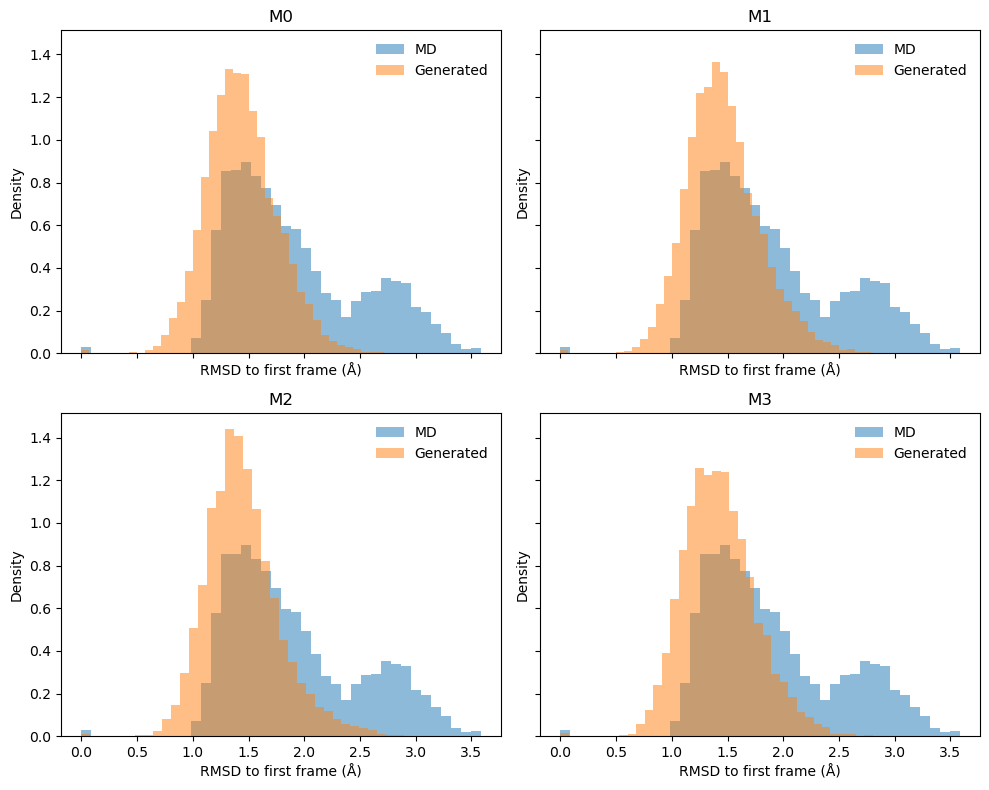

In [2]:
import matplotlib.pyplot as plt

model_labels = {
    "M0_simple_vae": "M0",
    "M1_kl_annealing": "M1",
    "M2_residual": "M2",
    "M3_final_attention": "M3"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, ablation in zip(axes, ablations):
    sub = df_rmsd[df_rmsd["ablation"] == ablation]

    md_vals = sub[sub["source"] == "MD"]["rmsd"]
    gen_vals = sub[sub["source"] == "Generated"]["rmsd"]

    ax.hist(md_vals, bins=40, alpha=0.5, density=True, label="MD")
    ax.hist(gen_vals, bins=40, alpha=0.5, density=True, label="Generated")

    ax.set_title(model_labels[ablation])
    ax.set_xlabel("RMSD to first frame (Å)")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("Figure_model_selection_RMSD_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
df_all.groupby(["protein","ablation"])[
    ["acceptance_rate",
     "best_val_recon",
     "rmsd_mean_diff"]
].mean()

acceptance_rate  best_val_recon  rmsd_mean_diff
protein  ablation                                                           
3UTQ     M0_simple_vae              0.127944        0.897181        0.677529
         M1_kl_annealing            0.120936        0.894054        0.625450
         M2_residual                0.147325        0.905467        0.683938
         M3_final_attention         0.136834        0.915979        0.654955
5C0F     M0_simple_vae              0.353654        1.124926        0.391228
         M1_kl_annealing            0.357235        1.120877        0.383081
         M2_residual                0.284225        1.135332        0.337312
         M3_final_attention         0.276871        1.129485        0.389935
5N1Y     M0_simple_vae              0.208359        0.957973        0.519500
         M1_kl_annealing            0.213867        0.953445        0.512468
         M2_residual                0.133768        0.965439        0.443021
         M3_final_attention         0.203744        0.950394        0.461452
pep_free M0_simple_vae              0.995117        0.616732        0.403767
         M1_kl_annealing            0.996419        0.618233        0.393842
         M2_residual                0.991862        0.631974        0.455530
         M3_final_attention         0.998372        0.605317        0.476226